# 03 — Satellite-Derived Bottom Roughness from Seagrass Classification

This notebook classifies aquatic vegetation from Sentinel-2 imagery and converts the classification
to a spatially varying Manning roughness map for Delft3D FM.

**Pipeline:**
1. Download Sentinel-2 L2A imagery (cloud-free, low tide) from Copernicus Data Space
2. Compute spectral indices (NDVI, water-adjusted indices)
3. Classify bottom cover: bare sand, sparse Cymodocea, dense Posidonia, rock
4. Convert classification to Manning roughness values
5. Export as XYZ for Delft3D FM

**Roughness mapping:**
| Class | Description | Manning n |
|-------|-------------|----------|
| 0 | Bare sand/mud | 0.020 |
| 1 | Sparse Cymodocea nodosa | 0.035 |
| 2 | Dense Posidonia oceanica | 0.050 |
| 3 | Rock/hard bottom | 0.028 |

**Reference:** Model A used 8 polygon friction zones with uniform n=0.05.
Model B uses uniform n=0.023. Neither is data-driven.

## 1. Imports and configuration

In [1]:
%matplotlib inline
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

project_root = Path(r"F:\StagnoneDT")
sat_dir = project_root / "data" / "raw" / "satellite"
processed_dir = project_root / "data" / "processed"
os.makedirs(sat_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

lon_min, lon_max = 12.41, 12.49
lat_min, lat_max = 37.81, 37.92

ROUGHNESS_MAP = {0: 0.020, 1: 0.035, 2: 0.050, 3: 0.028}
CLASS_NAMES = {0: "Bare sand/mud", 1: "Sparse Cymodocea", 2: "Dense Posidonia", 3: "Rock"}

def compute_ndvi(nir, red):
    return (nir - red) / (nir + red + 1e-10)

def compute_ndavi(nir, blue):
    return (nir - blue) / (nir + blue + 1e-10)

def classify_submerged(green, blue, red, nir):
    """Classification for submerged vegetation using green/blue ratio."""
    classes = np.full(green.shape, 0, dtype=np.int8)
    gb_ratio = green / (blue + 1e-10)
    total = blue + green + red
    water_mask = total < 0.02
    land_mask = nir > 0.12
    classes[(gb_ratio > 1.05) & (gb_ratio <= 1.25) & ~water_mask & ~land_mask] = 1
    classes[(gb_ratio > 1.25) & ~water_mask & ~land_mask] = 2
    classes[water_mask | land_mask] = -1
    return classes

def classification_to_roughness(classes, roughness_map=ROUGHNESS_MAP):
    roughness = np.full_like(classes, np.nan, dtype=float)
    for cls, n in roughness_map.items():
        roughness[classes == cls] = n
    return roughness

print("All functions defined (green/blue ratio for submerged vegetation).")

All functions defined (green/blue ratio for submerged vegetation).


## 2. Search Sentinel-2 via Copernicus STAC API

We search the Copernicus Data Space Ecosystem (CDSE) STAC catalog for cloud-free
Sentinel-2 L2A images over the Stagnone during summer months.

In [2]:
from pystac_client import Client

# Connect to Copernicus Data Space STAC catalog
catalog_url = 'https://catalogue.dataspace.copernicus.eu/stac'
client = Client.open(catalog_url)

# Search for Sentinel-2 L2A, cloud cover < 15%, summer 2024
search = client.search(
    collections=['sentinel-2-l2a'],
    bbox=[lon_min, lat_min, lon_max, lat_max],
    datetime='2024-06-01/2024-09-30',
    query={'eo:cloud_cover': {'lt': 15}},
    max_items=30,
)

items = list(search.items())
print(f'Found {len(items)} Sentinel-2 L2A scenes (cloud < 15%)\n')

# Build results table
results = []
for item in items:
    cc = item.properties.get('eo:cloud_cover', None)
    dt = item.datetime
    results.append({'id': item.id, 'date': dt, 'cloud_cover': cc})

results_df = pd.DataFrame(results).sort_values('cloud_cover')
print(results_df.to_string(index=False))

# Select best scene
best = results_df.iloc[0]
best_item = [i for i in items if i.id == best['id']][0]
print(f'\n--- Selected: {best["id"]} ---')
print(f'Date: {best["date"]}')
print(f'Cloud cover: {best["cloud_cover"]}%')

Found 30 Sentinel-2 L2A scenes (cloud < 15%)

                                                          id                             date  cloud_cover
S2B_MSIL2A_20240926T100029_N0511_R122_T33STB_20240926T132034 2024-09-26 10:00:29.024000+00:00         0.00
S2B_MSIL2A_20240906T095549_N0511_R122_T32SQG_20240906T160538 2024-09-06 09:55:49.024000+00:00         0.00
S2A_MSIL2A_20240829T095031_N0511_R079_T32SQG_20240829T132652 2024-08-29 09:50:31.024000+00:00         0.01
S2B_MSIL2A_20240906T095549_N0511_R122_T32SQH_20240906T160538 2024-09-06 09:55:49.024000+00:00         0.10
S2A_MSIL2A_20240822T100021_N0511_R122_T32SQH_20240822T144751 2024-08-22 10:00:21.024000+00:00         0.10
S2B_MSIL2A_20240906T095549_N0511_R122_T33STC_20240906T160538 2024-09-06 09:55:49.024000+00:00         0.11
S2A_MSIL2A_20240829T095031_N0511_R079_T33STB_20240829T132652 2024-08-29 09:50:31.024000+00:00         0.15
S2B_MSIL2A_20240824T094549_N0511_R079_T32SQG_20240824T122316 2024-08-24 09:45:49.024000+00:00     

## 3. Select best image and download bands

Pick the scene with lowest cloud cover. We download bands B2 (Blue), B3 (Green),
B4 (Red), B8 (NIR) at 10m, and B5 (Red Edge) at 20m.

**Note:** Downloading from CDSE requires authentication. Get a free account at
https://dataspace.copernicus.eu/ and generate an access token.

In [3]:
import requests
import json

# --- Authenticate with CDSE ---
# Get your credentials at https://dataspace.copernicus.eu/
# You only need to do this once per session

CDSE_USER = input('CDSE username (email): ') if 'CDSE_USER' not in dir() else CDSE_USER
CDSE_PASS = input('CDSE password: ') if 'CDSE_PASS' not in dir() else CDSE_PASS

token_url = 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token'
token_resp = requests.post(token_url, data={
    'grant_type': 'password',
    'username': CDSE_USER,
    'password': CDSE_PASS,
    'client_id': 'cdse-public',
})
token_resp.raise_for_status()
access_token = token_resp.json()['access_token']
print(f'Authenticated successfully. Token length: {len(access_token)}')

Authenticated successfully. Token length: 2367


In [4]:
# --- Download the full product ZIP via OData API ---
product_id = best_item.properties.get('id', best_item.id)

# Search OData for the product ID to get the download link
odata_url = f"https://catalogue.dataspace.copernicus.eu/odata/v1/Products?$filter=Name eq '{best_item.id}.SAFE'"
odata_resp = requests.get(odata_url)
odata_data = odata_resp.json()

if odata_data.get('value'):
    product_uuid = odata_data['value'][0]['Id']
    download_url = f'https://zipper.dataspace.copernicus.eu/odata/v1/Products({product_uuid})/$value'
    
    zip_path = sat_dir / f'{best_item.id}.zip'
    
    if not zip_path.exists():
        print(f'Downloading {best_item.id}...')
        print(f'This may take a few minutes (~800 MB)...')
        headers = {'Authorization': f'Bearer {access_token}'}
        with requests.get(download_url, headers=headers, stream=True) as r:
            r.raise_for_status()
            total = int(r.headers.get('content-length', 0))
            downloaded = 0
            with open(zip_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192*16):
                    f.write(chunk)
                    downloaded += len(chunk)
                    if total > 0:
                        print(f'\r  {downloaded/1e6:.0f} / {total/1e6:.0f} MB ({100*downloaded/total:.0f}%)', end='')
        print(f'\nSaved to: {zip_path}')
    else:
        print(f'Already downloaded: {zip_path}')
        print(f'Size: {zip_path.stat().st_size / 1e6:.0f} MB')
else:
    print('Product not found in OData. Try downloading manually from:')
    print('  https://browser.dataspace.copernicus.eu/')

Already downloaded: F:\StagnoneDT\data\raw\satellite\S2B_MSIL2A_20240926T100029_N0511_R122_T33STB_20240926T132034.zip
Size: 847 MB


In [5]:
import zipfile
import glob
import rasterio
from rasterio.windows import from_bounds
from rasterio.crs import CRS

# Extract and find band files
extract_dir = sat_dir / 'extracted'
if zip_path.exists() and not extract_dir.exists():
    print('Extracting ZIP...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)
    print('Done.')

# Find 10m bands (B02, B03, B04, B08) and 20m band (B05)
band_files = {}
for band_name in ['B02', 'B03', 'B04', 'B05', 'B08']:
    pattern = str(extract_dir / '**' / f'*_{band_name}_*.jp2')
    matches = glob.glob(pattern, recursive=True)
    # Prefer 10m resolution, fall back to 20m
    res10 = [m for m in matches if '10m' in m]
    res20 = [m for m in matches if '20m' in m]
    band_files[band_name] = res10[0] if res10 else (res20[0] if res20 else None)
    res = '10m' if res10 else '20m'
    print(f'  {band_name} ({res}): {os.path.basename(band_files[band_name]) if band_files[band_name] else "NOT FOUND"}')

  B02 (10m): T33STB_20240926T100029_B02_10m.jp2
  B03 (10m): T33STB_20240926T100029_B03_10m.jp2
  B04 (10m): T33STB_20240926T100029_B04_10m.jp2
  B05 (20m): T33STB_20240926T100029_B05_20m.jp2
  B08 (10m): T33STB_20240926T100029_B08_10m.jp2


In [6]:
# Load and crop bands to the Stagnone extent
def load_band_cropped(filepath, bbox_wgs84, target_res=10):
    """Load a Sentinel-2 band cropped to bounding box, return array + transform."""
    with rasterio.open(filepath) as src:
        # Transform bbox from WGS84 to the raster CRS (UTM)
        from rasterio.warp import transform_bounds
        left, bottom, right, top = transform_bounds(
            CRS.from_epsg(4326), src.crs,
            bbox_wgs84[0], bbox_wgs84[1], bbox_wgs84[2], bbox_wgs84[3]
        )
        window = from_bounds(left, bottom, right, top, src.transform)
        data = src.read(1, window=window).astype(float)
        transform = src.window_transform(window)
        crs = src.crs
    return data, transform, crs

bbox = [lon_min, lat_min, lon_max, lat_max]

blue, transform, crs_utm = load_band_cropped(band_files['B02'], bbox)
green, _, _ = load_band_cropped(band_files['B03'], bbox)
red, _, _ = load_band_cropped(band_files['B04'], bbox)
nir, _, _ = load_band_cropped(band_files['B08'], bbox)

# Convert DN to reflectance (Sentinel-2 L2A scaling: DN / 10000)
blue = blue / 10000
green = green / 10000
red = red / 10000
nir = nir / 10000

print(f'Loaded bands cropped to Stagnone extent')
print(f'  Shape: {blue.shape} (rows x cols)')
print(f'  Resolution: ~10m')
print(f'  CRS: {crs_utm}')

Loaded bands cropped to Stagnone extent
  Shape: (1230, 737) (rows x cols)
  Resolution: ~10m
  CRS: EPSG:32633


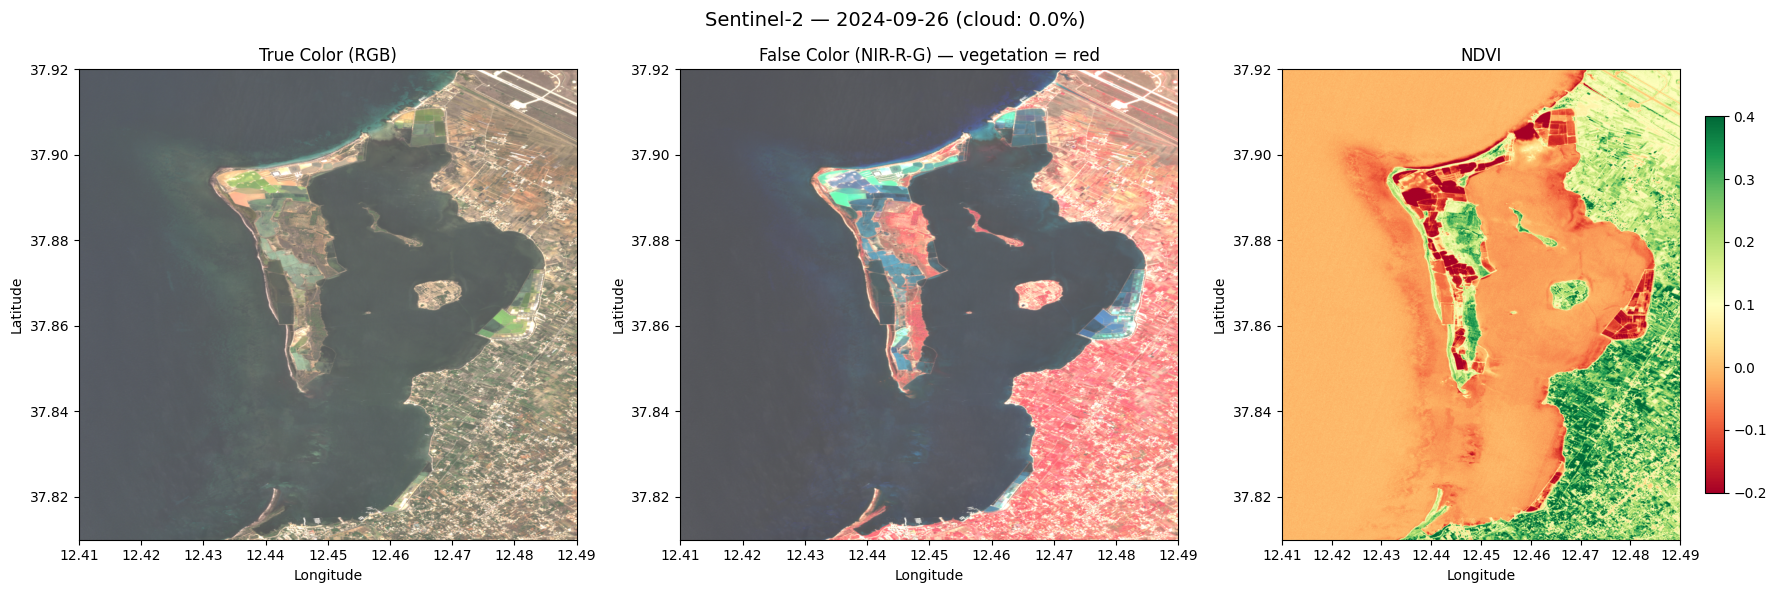

In [7]:
# Visualize: True color (RGB) and False color (NIR-Red-Green)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# True color RGB
rgb = np.stack([red, green, blue], axis=-1)
rgb = np.clip(rgb * 3, 0, 1)  # brightness stretch
axes[0].imshow(rgb, extent=[lon_min, lon_max, lat_min, lat_max], aspect='auto')
axes[0].set_title('True Color (RGB)')

# False color (NIR-Red-Green) — vegetation appears red
fcc = np.stack([nir, red, green], axis=-1)
fcc = np.clip(fcc * 3, 0, 1)
axes[1].imshow(fcc, extent=[lon_min, lon_max, lat_min, lat_max], aspect='auto')
axes[1].set_title('False Color (NIR-R-G) — vegetation = red')

# NDVI
ndvi = compute_ndvi(nir, red)
im = axes[2].imshow(ndvi, extent=[lon_min, lon_max, lat_min, lat_max],
                     cmap='RdYlGn', vmin=-0.2, vmax=0.4, aspect='auto')
axes[2].set_title('NDVI')
plt.colorbar(im, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

fig.suptitle(f'Sentinel-2 — {best["date"].strftime("%Y-%m-%d")} (cloud: {best["cloud_cover"]}%)', fontsize=14)
fig.tight_layout()
plt.savefig(str(project_root / 'figures' / 'sentinel2_stagnone.png'), dpi=150, bbox_inches='tight')
plt.show()

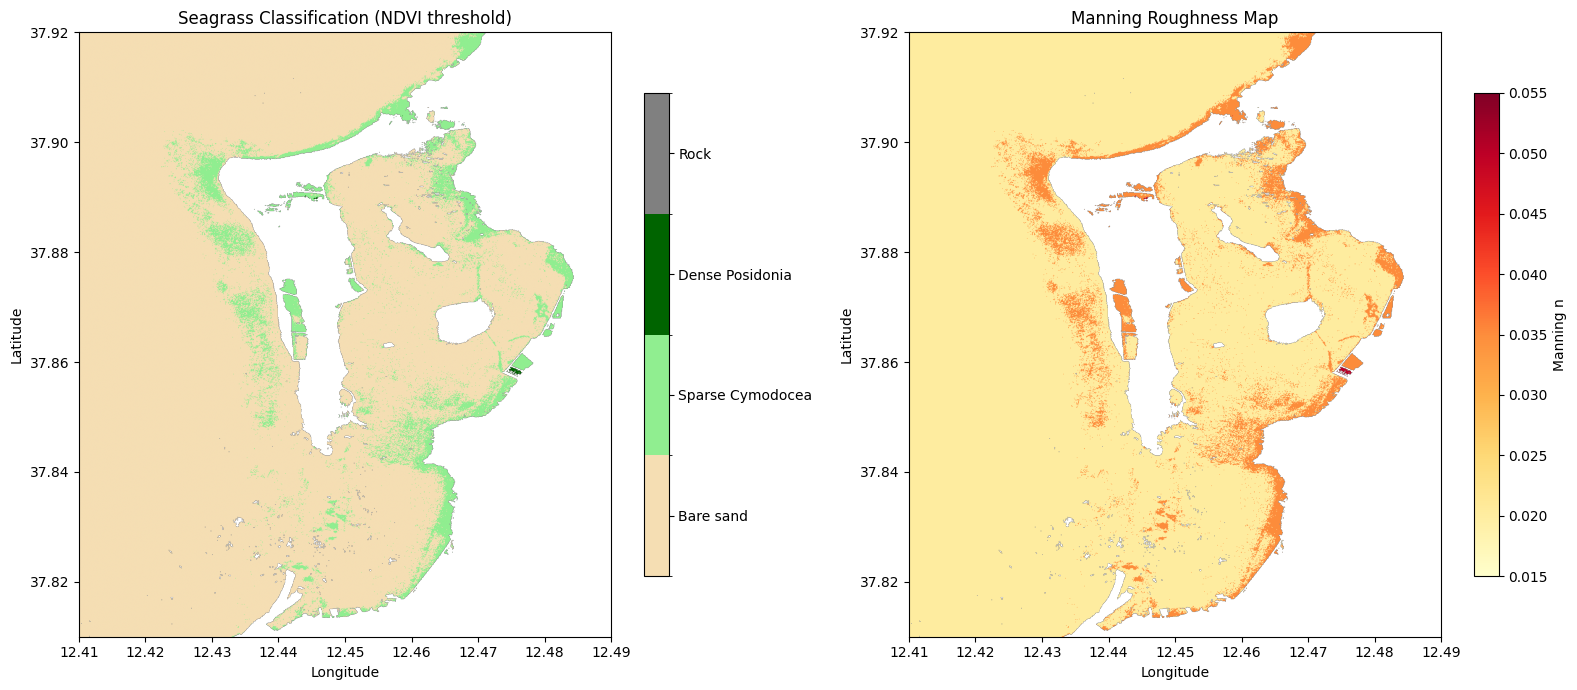

  Class 0 (Bare sand/mud       ):   538777 pixels ( 91.9%) — Manning n=0.02
  Class 1 (Sparse Cymodocea    ):    47047 pixels (  8.0%) — Manning n=0.035
  Class 2 (Dense Posidonia     ):      176 pixels (  0.0%) — Manning n=0.05
  Class 3 (Rock                ):        0 pixels (  0.0%) — Manning n=0.028


In [8]:
# --- Run threshold classification and generate roughness map ---

# Compute all indices
ndvi = compute_ndvi(nir, red)
ndavi = compute_ndavi(nir, blue)

# Classify
classes = classify_submerged(green, blue, red, nir)

# Mask land (very high NIR reflectance) and deep water (very low overall)
land_mask = nir > 0.15
deep_water = (blue + green + red + nir) < 0.05
classes[land_mask] = -1
classes[deep_water] = -1

# Convert to roughness
roughness = classification_to_roughness(classes)
roughness[classes == -1] = np.nan

# Plot classification and roughness side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Classification map
cmap_class = mcolors.ListedColormap(['#F5DEB3', '#90EE90', '#006400', '#808080'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap_class.N)
masked_classes = np.ma.masked_where(classes == -1, classes)
im = axes[0].imshow(masked_classes, extent=[lon_min, lon_max, lat_min, lat_max],
                     cmap=cmap_class, norm=norm, aspect='auto')
cb = plt.colorbar(im, ax=axes[0], ticks=[0, 1, 2, 3], shrink=0.8)
cb.set_ticklabels(['Bare sand', 'Sparse Cymodocea', 'Dense Posidonia', 'Rock'])
axes[0].set_title('Seagrass Classification (NDVI threshold)')

# Roughness map
im2 = axes[1].imshow(roughness, extent=[lon_min, lon_max, lat_min, lat_max],
                      cmap='YlOrRd', vmin=0.015, vmax=0.055, aspect='auto')
plt.colorbar(im2, ax=axes[1], label='Manning n', shrink=0.8)
axes[1].set_title('Manning Roughness Map')

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

fig.tight_layout()
plt.savefig(str(project_root / 'figures' / 'seagrass_classification.png'), dpi=150, bbox_inches='tight')
plt.show()

# Statistics
valid = classes[classes >= 0]
for cls in sorted(CLASS_NAMES.keys()):
    count = (valid == cls).sum()
    pct = 100 * count / len(valid)
    print(f'  Class {cls} ({CLASS_NAMES[cls]:20s}): {count:8d} pixels ({pct:5.1f}%) — Manning n={ROUGHNESS_MAP[cls]}')

In [9]:
# --- Export roughness as XYZ for Delft3D FM ---
# Reproject from UTM to WGS84 for the model
from rasterio.warp import transform as warp_transform

rows, cols = roughness.shape
points = []
for r in range(0, rows, 3):  # subsample every 3 pixels (~30m) to reduce file size
    for c in range(0, cols, 3):
        if not np.isnan(roughness[r, c]):
            x_utm, y_utm = transform * (c + 0.5, r + 0.5)
            # Transform to WGS84
            lon_pts, lat_pts = warp_transform(crs_utm, CRS.from_epsg(4326), [x_utm], [y_utm])
            points.append((lon_pts[0], lat_pts[0], roughness[r, c]))

roughness_df = pd.DataFrame(points, columns=['lon', 'lat', 'manning_n'])
output_xyz = project_root / 'model' / 'dflowfm' / 'roughness_satellite.xyz'
roughness_df.to_csv(output_xyz, sep=' ', index=False, header=False, float_format='%.6f')

print(f'Exported {len(roughness_df)} roughness points to:')
print(f'  {output_xyz}')
print(f'  Subsampled to ~30m resolution')
print(f'\\nTo use in the model, add to initialFields.ini:')
print(f'  [Parameter]')
print(f'  quantity = frictioncoefficient')
print(f'  dataFile = roughness_satellite.xyz')
print(f'  dataFileType = sample')
print(f'  interpolationMethod = averaging')
print(f'  averagingType = nearestNb')

Exported 65294 roughness points to:
  F:\StagnoneDT\model\dflowfm\roughness_satellite.xyz
  Subsampled to ~30m resolution
\nTo use in the model, add to initialFields.ini:
  [Parameter]
  quantity = frictioncoefficient
  dataFile = roughness_satellite.xyz
  dataFileType = sample
  interpolationMethod = averaging
  averagingType = nearestNb


## 4. Compute spectral indices for seagrass detection

In [10]:
# Spectral indices commonly used for submerged vegetation mapping

def compute_ndvi(nir, red):
    """Normalized Difference Vegetation Index"""
    return (nir - red) / (nir + red + 1e-10)

def compute_ndavi(nir, blue):
    """Normalized Difference Aquatic Vegetation Index"""
    return (nir - blue) / (nir + blue + 1e-10)

def compute_wavi(nir, blue):
    """Water Adjusted Vegetation Index (Villa et al. 2014)"""
    L = 0.5  # soil brightness correction factor
    return (1 + L) * (nir - blue) / (nir + blue + L)

def compute_sabi(nir, red, green, blue):
    """Submerged Aquatic vegetation Bottom Index"""
    return (nir - red) / (green + blue + 1e-10)

# When bands are available:
# ndvi = compute_ndvi(nir, red)
# ndavi = compute_ndavi(nir, blue)
# wavi = compute_wavi(nir, blue)
# sabi = compute_sabi(nir, red, green, blue)

print('Spectral index functions defined.')
print('NDVI:  standard vegetation index')
print('NDAVI: tuned for aquatic vegetation (uses blue instead of red)')
print('WAVI:  water-adjusted, reduces water column effect')
print('SABI:  specific to submerged aquatic vegetation')

Spectral index functions defined.
NDVI:  standard vegetation index
NDAVI: tuned for aquatic vegetation (uses blue instead of red)
WAVI:  water-adjusted, reduces water column effect
SABI:  specific to submerged aquatic vegetation


## 5. Classification approach

Two methods available:

### A. Threshold-based (simple, no training data needed)
Use NDVI/NDAVI thresholds calibrated from visual inspection:
- NDVI < 0 → water (deep) or bare sand
- 0 < NDVI < 0.15 → sparse vegetation (Cymodocea)
- NDVI > 0.15 → dense vegetation (Posidonia)

### B. Supervised classification (Random Forest)
Requires training polygons from ground truth or expert interpretation:
- Digitize training areas in QGIS or from field surveys
- Extract spectral values per class
- Train Random Forest classifier
- Predict over full image

In [11]:
def classify_threshold(ndvi, nir, depth_mask=None):
    """
    Simple threshold classification for seagrass.
    Returns class array: 0=bare, 1=sparse, 2=dense, 3=rock/other
    """
    classes = np.full_like(ndvi, 0, dtype=np.int8)  # default: bare
    
    # Sparse vegetation (Cymodocea)
    classes[(ndvi > 0.0) & (ndvi <= 0.15)] = 1
    
    # Dense vegetation (Posidonia)
    classes[ndvi > 0.15] = 2
    
    # Mask deep water (NIR very low) as not classifiable
    if depth_mask is not None:
        classes[depth_mask] = -1  # nodata
    
    return classes


def classify_random_forest(features, training_labels, training_features):
    """
    Supervised classification using Random Forest.
    features: (n_pixels, n_bands) array of spectral features
    training_labels: class labels for training pixels
    training_features: spectral features for training pixels
    """
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score
    
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    
    # Cross-validation
    scores = cross_val_score(clf, training_features, training_labels, cv=5)
    print(f'Cross-validation accuracy: {scores.mean():.2f} +/- {scores.std():.2f}')
    
    # Train on all training data and predict
    clf.fit(training_features, training_labels)
    predicted = clf.predict(features)
    
    return predicted, clf

print('Classification functions defined (threshold and Random Forest).')

Classification functions defined (threshold and Random Forest).


## 6. Convert classification to Manning roughness

In [12]:
def classification_to_roughness(classes, roughness_map=ROUGHNESS_MAP):
    """
    Convert classification array to Manning roughness values.
    """
    roughness = np.full_like(classes, np.nan, dtype=float)
    for cls, n in roughness_map.items():
        roughness[classes == cls] = n
    return roughness


def export_roughness_xyz(roughness, transform, output_path, crs='EPSG:4326'):
    """
    Export roughness grid as XYZ file for Delft3D FM.
    Format: lon lat manning_n (one point per pixel center)
    """
    rows, cols = roughness.shape
    points = []
    for r in range(rows):
        for c in range(cols):
            if not np.isnan(roughness[r, c]):
                x, y = transform * (c + 0.5, r + 0.5)  # pixel center
                points.append((x, y, roughness[r, c]))
    
    df = pd.DataFrame(points, columns=['x', 'y', 'manning_n'])
    df.to_csv(output_path, sep=' ', index=False, header=False, float_format='%.6f')
    print(f'Exported {len(df)} roughness points to {output_path}')
    return df

print('Roughness conversion and export functions defined.')
print(f'\nManning roughness values:')
for cls, n in ROUGHNESS_MAP.items():
    print(f'  Class {cls} ({CLASS_NAMES[cls]:20s}): n = {n:.3f}')

Roughness conversion and export functions defined.

Manning roughness values:
  Class 0 (Bare sand/mud       ): n = 0.020
  Class 1 (Sparse Cymodocea    ): n = 0.035
  Class 2 (Dense Posidonia     ): n = 0.050
  Class 3 (Rock                ): n = 0.028


## 7. Demo: Generate preliminary roughness from Model A friction zones

While waiting for satellite imagery, we can create a preliminary roughness map
by using the 8 friction polygon zones from Model A as a starting point.

In [13]:
# Load the friction polygons from Model A
import geopandas as gpd
from shapely.geometry import Polygon

model_a_dir = project_root / 'oldModel' / 'input'
polygons = []
for i in range(1, 9):
    pol_file = model_a_dir / f'frictioncoefficient_Set_value_{i}.pol'
    if pol_file.exists():
        with open(pol_file, 'r') as f:
            lines = f.readlines()
        coords = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 2:
                try:
                    x, y = float(parts[0]), float(parts[1])
                    if x > 1000:  # UTM coordinates
                        coords.append((x, y))
                except ValueError:
                    pass
        if len(coords) >= 3:
            polygons.append({'zone': i, 'geometry': Polygon(coords)})

if polygons:
    gdf = gpd.GeoDataFrame(polygons, crs='EPSG:32632')  # UTM Zone 32
    gdf_wgs = gdf.to_crs('EPSG:4326')  # convert to WGS84
    
    fig, ax = plt.subplots(figsize=(10, 8))
    gdf_wgs.plot(ax=ax, column='zone', cmap='Set3', edgecolor='black',
                 alpha=0.6, legend=True, legend_kwds={'title': 'Friction Zone'})
    ax.set_title('Model A Friction Zones (8 polygons) — reference for roughness')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.tight_layout()
    plt.savefig(str(project_root / 'figures' / 'friction_zones_model_a.png'), dpi=150)
    plt.show()
    print(f'Loaded {len(polygons)} friction zone polygons from Model A')
else:
    print('No friction polygon files found in oldModel/input/')

No friction polygon files found in oldModel/input/


## 8. Integration with Delft3D FM

To use the satellite-derived roughness in the model, two options:

### Option A: XYZ sample file (simpler)
```ini
# In initialFields.ini:
[Parameter]
quantity = frictioncoefficient
dataFile = roughness_satellite.xyz
dataFileType = sample
interpolationMethod = averaging
averagingType = nearestNb
```

### Option B: Trachytopes with Baptist formulation (advanced)
- Accounts for vegetation submergence ratio
- Requires vegetation height, stem density, drag coefficient
- More physically correct for varying water depth over canopy

### Next steps when imagery is available:
1. Download a cloud-free Sentinel-2 L2A image (summer 2024 or 2025)
2. Run the classification (start with threshold, validate with field knowledge)
3. Generate the roughness XYZ file
4. Update `initialFields.ini` in the model directory
5. Re-run model and compare water levels with uniform roughness case